In [1]:
import warnings

import pandas as pd

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pertpy as pt
import scanpy as sc
import seaborn as sns

In [2]:
# Load in data

# import preprocessed dataset

dir = "PBMC_datasets/5/PBMC5_clustering.h5ad"

adata = sc.read(dir)

In [3]:
# Compositional analysis (using scCODA)

#instantiate scCODA model and create MuData object 

sccoda_model = pt.tl.Sccoda()
sccoda_data = sccoda_model.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="celltypist_cell_label_coarse",
    sample_identifier="sample",
    covariate_obs=["diagnosis"],
)
sccoda_data

MuData object with n_obs × n_vars = 78900 × 20062
  var:	'n_cells'
  2 modalities
    rna:	78876 x 20053
      obs:	'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'sample', 'diagnosis', 'gender', 'age', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'Monocle3_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'manual_celltype_annotation_1', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'dendrogram_leiden_res1', 'final_anno_colors', 'final_broad_colors', 'gender_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res2', 'leiden_res2_colors', 'manual_celltype_annotation_0_25_colors', 'manual_celltype_annotation_1_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'log1p_norm'
      obsp:	'connectivities', 'distances'
    coda:	24 x 9
      obs:	'diagnosis', 'sample'
      var:	'n_cells'

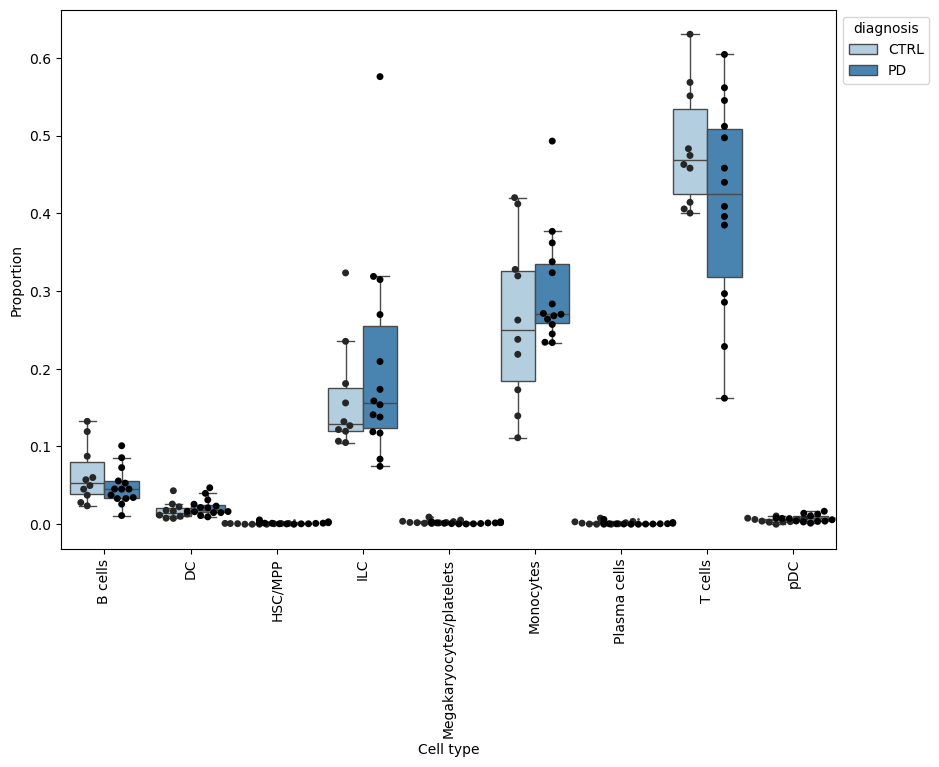

In [4]:
# get overview of cell type distributions w boxplots
sccoda_model.plot_boxplots(
    sccoda_data,
    modality_key="coda",
    feature_name="diagnosis",
    figsize=(10, 7),
    add_dots=True,
    args_swarmplot={"color": "red"},
)
plt.show()

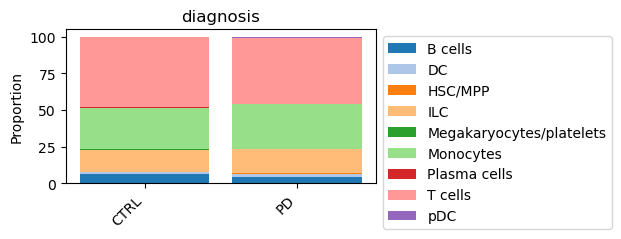

In [5]:
# alternative visualisation with stacked barplot

sccoda_model.plot_stacked_barplot(
    sccoda_data, modality_key="coda", feature_name="diagnosis", figsize=(4, 2)
)
plt.show()

In [6]:
# checking the baseline category for diagnosis (for interpretation of results later on)
sccoda_data["coda"].obs["diagnosis"].cat.categories

Index(['CTRL', 'PD'], dtype='object')

In [8]:
# run scCODA model
sccoda_data = sccoda_model.prepare(
    sccoda_data,
    modality_key="coda",
    formula="diagnosis",
    reference_cell_type="automatic", # letting scCODA choose the reference cell type automatically
)
sccoda_model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [01:24<00:00, 130.23it/s, 63 steps of size 3.91e-02. acc. prob=0.75] 


In [9]:
sccoda_data["coda"].varm["effect_df_diagnosis[T.PD]"]

,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
celltypist_cell_label_coarse,,,,,,,
B cells,0.0,-0.535,0.184,0.169,0.5258,184.924230,0.0
DC,0.0,-0.345,0.403,0.135,0.4715,81.202511,0.0
HSC/MPP,0.0,-0.339,0.553,0.171,0.4955,18.466276,0.0
ILC,0.0,-0.223,0.324,0.093,0.4059,530.566961,0.0
Megakaryocytes/platelets,0.0,0.000,0.000,0.000,0.0000,24.802543,0.0
Monocytes,0.0,-0.131,0.375,0.105,0.4514,846.361162,0.0
Plasma cells,0.0,-0.479,0.414,0.160,0.4810,19.219899,0.0
T cells,0.0,-0.514,0.002,0.161,0.8557,1542.170584,0.0
pDC,0.0,-0.371,0.481,0.160,0.4914,39.014999,0.0


In [ ]:
# from the above table, it seems none of the cell types are significantly differentially abundant between the two conditions (since all 95% credible intervals include 0). At FDR 0.05

In [ ]:
# trying with a less stringent FDR threshold to see if any cell types are identified as differentially abundant
sccoda_model.set_fdr(sccoda_data, 0.2)
credible = sccoda_model.credible_effects(sccoda_data, modality_key="coda")
credible
# under this FDR threshold, it looks like T cells are identified as significantly differentially abundant.

Covariate        Cell Type               
diagnosis[T.PD]  B cells                     False
                 DC                          False
                 HSC/MPP                     False
                 ILC                         False
                 Megakaryocytes/platelets    False
                 Monocytes                   False
                 Plasma cells                False
                 T cells                      True
                 pDC                         False
Name: Final Parameter, dtype: bool

In [11]:
# identify significant cell types for downstream analyses

# dictionary for stars
significance_mapping = {
    celltype: "*"
    for (effect, celltype), is_sig in credible.items()
    if is_sig
}

In [12]:
significance_mapping

{'T cells': '*'}

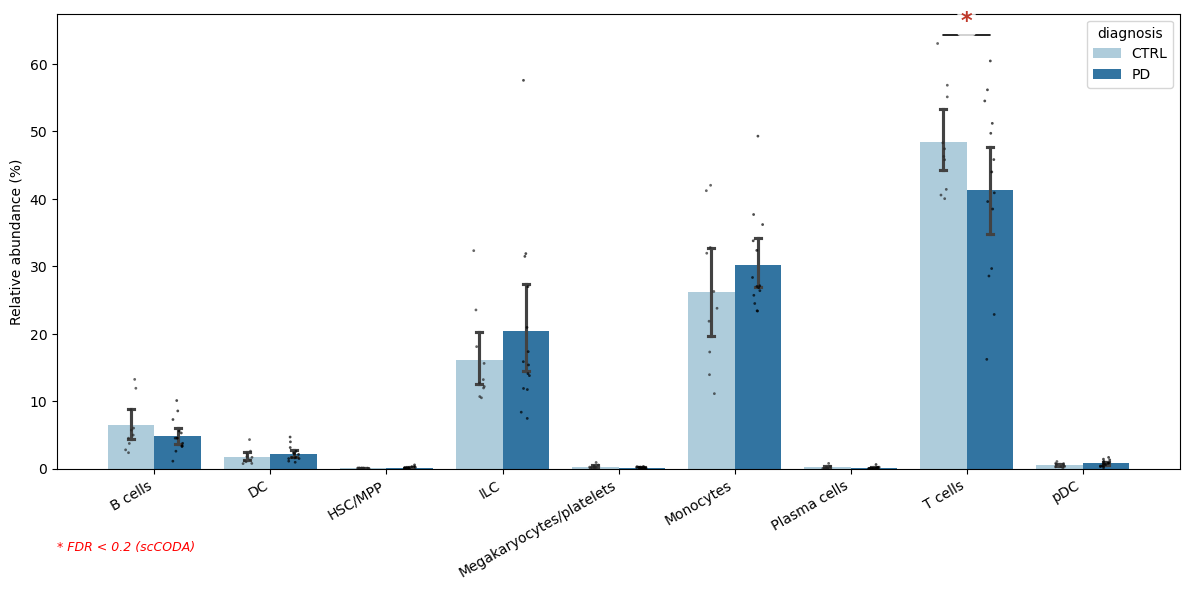

In [13]:
# plot relative abundances of cell types across the two conditions
coda = sccoda_data["coda"]

# Build relative-abundance long-format dataframe in one chain
plot_df = (
    pd.DataFrame(coda.X, index=coda.obs_names, columns=coda.var_names)
    .pipe(lambda df: df.div(df.sum(axis=1), axis=0) * 100)
    .assign(diagnosis=coda.obs["diagnosis"].values)
    .reset_index(names="sample")
    .melt(id_vars=["sample", "diagnosis"], var_name="cell_type", value_name="rel_abundance")
)

cell_types = plot_df["cell_type"].unique().tolist()

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=plot_df, x="cell_type", y="rel_abundance", hue="diagnosis",
    errorbar=("ci", 95), capsize=0.1, palette="Paired", ax=ax
)
sns.stripplot(
    data=plot_df, x="cell_type", y="rel_abundance", hue="diagnosis",
    dodge=True, color="black", alpha=0.7, size=2, legend=False, ax=ax
)

# Significance annotations 
PAD      = 1.2   # gap between bar top and bracket
TXT_PAD  = 0.4   # gap between bracket and asterisk

for ct, label in significance_mapping.items():
    x   = cell_types.index(ct)
    top = plot_df.loc[plot_df["cell_type"] == ct, "rel_abundance"].max()
    y_bracket = top + PAD
    y_text    = y_bracket + TXT_PAD

    # horizontal bracket line
    ax.plot(
        [x - 0.2, x + 0.2], [y_bracket, y_bracket],
        color="black", linewidth=1.2, solid_capstyle="round"
    )
    # asterisk with bold weight + contrasting background box
    ax.text(
        x, y_text, label,
        ha="center", va="bottom", fontsize=16, fontweight="bold", color="#C0392B",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8)
    )

ax.annotate(
    "* FDR < 0.2 (scCODA)",
    xy=(0, -0.18), xycoords="axes fraction",
    fontsize=9, color="red", style="italic"
)

ax.set_xlabel("")
ax.set_ylabel("Relative abundance (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



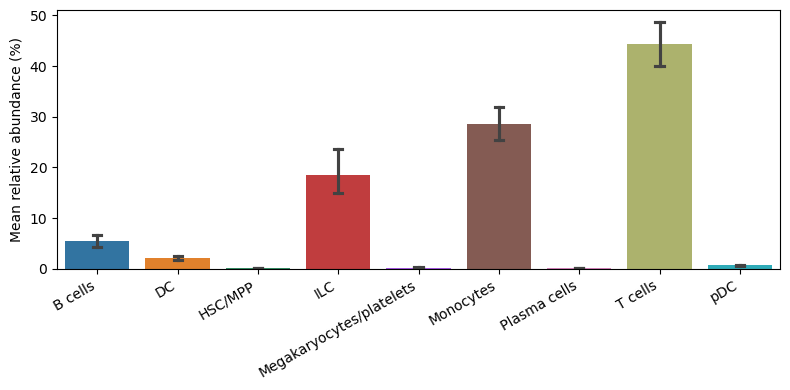

In [14]:
# plot overall relative abundance of each cell type across all samples with 95% CI, and colors corresponding to the cell types in UMAP

# count cells per type per sample, then normalise to %
plot_df = (
    adata.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

# derive colors from adata
labels = adata.obs["celltypist_cell_label_coarse"].astype("category").cat.categories
colors = adata.uns["celltypist_cell_label_coarse_colors"]
cell_type_colors_dict = dict(zip(labels, colors))

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="celltypist_cell_label_coarse",  # was "cell_type" — column doesn't exist yet
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()